In [2]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [3]:
# Load sample dataset used for paper comparison
original_bank = pd.read_csv("/Users/Owner/Desktop/Bank-Project/Datasets/bank/bank.csv", sep=";")

X = original_bank.drop(columns=["y"])
y = original_bank["y"].map({"no": 0, "yes": 1})

categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("Dataset shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

Dataset shape: (4521, 16)

Class distribution:
y
0    4000
1     521
Name: count, dtype: int64


In [4]:
#Preprocessing steps
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)
#Baseline pipeline keeping SMOTE as my approach comparing with undersampling

baseline_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

In [5]:
#10 fold CV as the author I am comparing used
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

In [6]:
#Fitting and Evaluating a baseline model with 10-fold CV
baseline_cv_results = cross_validate(
    baseline_pipeline,
    X,
    y,
    cv=cv10,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

baseline_summary = pd.DataFrame([{
    "Scenario": "LR + SMOTE (Baseline, 10-fold CV)",
    "Accuracy": baseline_cv_results["test_accuracy"].mean(),
    "Precision": baseline_cv_results["test_precision"].mean(),
    "Recall": baseline_cv_results["test_recall"].mean(),
    "F1-score": baseline_cv_results["test_f1"].mean(),
    "ROC-AUC": baseline_cv_results["test_roc_auc"].mean()
}])

print(baseline_summary.round(4))

                            Scenario  Accuracy  Precision  Recall  F1-score  \
0  LR + SMOTE (Baseline, 10-fold CV)    0.8365     0.3923  0.7619    0.5175   

   ROC-AUC  
0   0.8906  


In [7]:
#Hypertunning the model

param_grid = {
    "model__solver": ["lbfgs", "liblinear", "saga"],
    "model__C": [0.01, 0.1, 1, 3, 10, 30, 100],
    "model__class_weight": [None, "balanced"]
}


#Running GridSearchCV for manual grid of hyperparameters
lr_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv10,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

lr_search.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [8]:
print("Best parameters:")
print(lr_search.best_params_)

print("\nBest mean CV F1-score:")
print(round(lr_search.best_score_, 4))

Best parameters:
{'model__C': 0.1, 'model__class_weight': None, 'model__solver': 'saga'}

Best mean CV F1-score:
0.5187


In [9]:
# Rebuild tuned pipeline using best parameters
tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("lr", LogisticRegression(
        solver=lr_search.best_params_["model__solver"],
        C=lr_search.best_params_["model__C"],
        class_weight=lr_search.best_params_["model__class_weight"],
        max_iter=5000,
        random_state=42
    ))
])

tuned_cv_results = cross_validate(
    tuned_pipeline,
    X,
    y,
    cv=cv10,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

tuned_summary = pd.DataFrame([{
    "Scenario": "LR + SMOTE (Tuned GridSearchCV, 10-fold CV)",
    "Accuracy": tuned_cv_results["test_accuracy"].mean(),
    "Precision": tuned_cv_results["test_precision"].mean(),
    "Recall": tuned_cv_results["test_recall"].mean(),
    "F1-score": tuned_cv_results["test_f1"].mean(),
    "ROC-AUC": tuned_cv_results["test_roc_auc"].mean()
}])

print(tuned_summary.round(4))

                                      Scenario  Accuracy  Precision  Recall  \
0  LR + SMOTE (Tuned GridSearchCV, 10-fold CV)    0.8365     0.3926  0.7657   

   F1-score  ROC-AUC  
0    0.5187   0.8922  


In [10]:
# Comparing the tuned model against the baseline
results_df = pd.concat([baseline_summary, tuned_summary], ignore_index=True)
print(results_df.round(4))

                                      Scenario  Accuracy  Precision  Recall  \
0            LR + SMOTE (Baseline, 10-fold CV)    0.8365     0.3923  0.7619   
1  LR + SMOTE (Tuned GridSearchCV, 10-fold CV)    0.8365     0.3926  0.7657   

   F1-score  ROC-AUC  
0    0.5175   0.8906  
1    0.5187   0.8922  


In [11]:
# Optional: fold-by-fold results for baseline
baseline_folds_df = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": baseline_cv_results["test_accuracy"],
    "Precision": baseline_cv_results["test_precision"],
    "Recall": baseline_cv_results["test_recall"],
    "F1-score": baseline_cv_results["test_f1"],
    "ROC-AUC": baseline_cv_results["test_roc_auc"]
})

# Optional: fold-by-fold results for tuned model
tuned_folds_df = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": tuned_cv_results["test_accuracy"],
    "Precision": tuned_cv_results["test_precision"],
    "Recall": tuned_cv_results["test_recall"],
    "F1-score": tuned_cv_results["test_f1"],
    "ROC-AUC": tuned_cv_results["test_roc_auc"]
})

print("Baseline fold results:")
print(baseline_folds_df.round(4))

print("\nTuned fold results:")
print(tuned_folds_df.round(4))

Baseline fold results:
   Fold  Accuracy  Precision  Recall  F1-score  ROC-AUC
0     1    0.8389     0.4057  0.8113    0.5409   0.8923
1     2    0.8274     0.3617  0.6538    0.4658   0.8758
2     3    0.8252     0.3738  0.7692    0.5031   0.8699
3     4    0.8518     0.4176  0.7308    0.5315   0.8960
4     5    0.8518     0.4242  0.8077    0.5563   0.9184
5     6    0.8208     0.3619  0.7308    0.4841   0.8800
6     7    0.8496     0.4286  0.9231    0.5854   0.9356
7     8    0.8208     0.3592  0.7115    0.4774   0.8763
8     9    0.8252     0.3636  0.6923    0.4768   0.8486
9    10    0.8540     0.4271  0.7885    0.5541   0.9137

Tuned fold results:
   Fold  Accuracy  Precision  Recall  F1-score  ROC-AUC
0     1    0.8322     0.3945  0.8113    0.5309   0.8890
1     2    0.8296     0.3684  0.6731    0.4762   0.8775
2     3    0.8274     0.3796  0.7885    0.5125   0.8722
3     4    0.8473     0.4086  0.7308    0.5241   0.8993
4     5    0.8407     0.4020  0.7885    0.5325   0.9181
5   

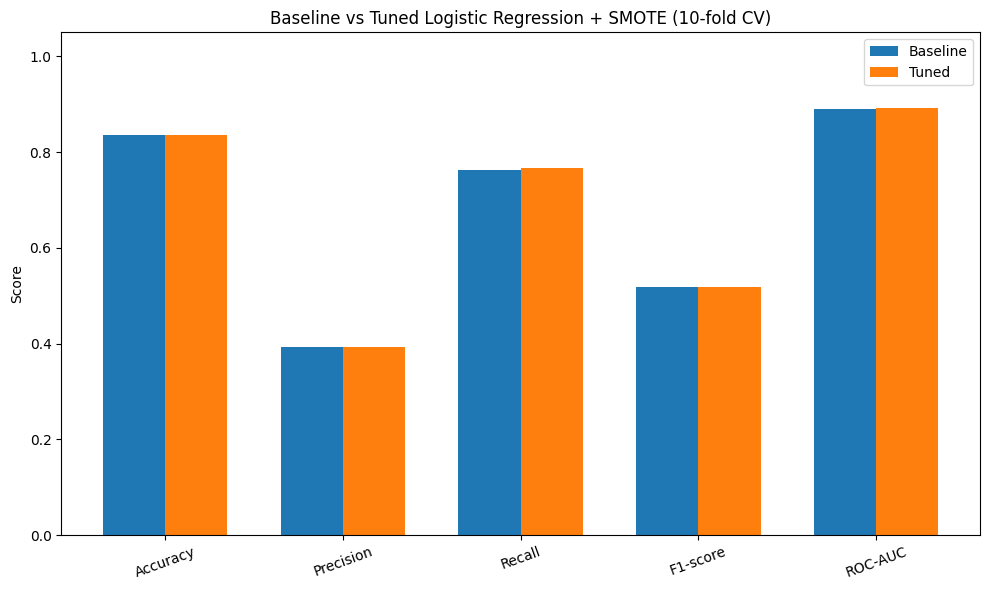

In [12]:
#Grouped bar plot
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

baseline_values = results_df.loc[0, metrics].values
tuned_values = results_df.loc[1, metrics].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, baseline_values, width, label="Baseline")
plt.bar(x + width/2, tuned_values, width, label="Tuned")

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Score")
plt.title("Baseline vs Tuned Logistic Regression + SMOTE (10-fold CV)")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

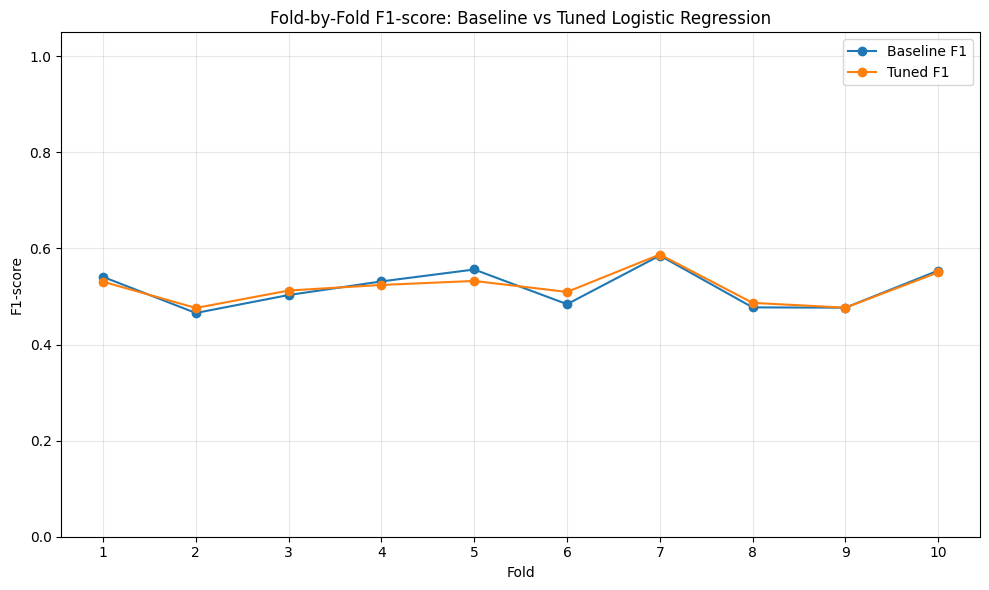

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(baseline_folds_df["Fold"], baseline_folds_df["F1-score"], marker="o", label="Baseline F1")
plt.plot(tuned_folds_df["Fold"], tuned_folds_df["F1-score"], marker="o", label="Tuned F1")

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Fold-by-Fold F1-score: Baseline vs Tuned Logistic Regression")
plt.xticks(range(1, 11))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
comparison_with_std = pd.DataFrame([
    {
        "Scenario": "LR + SMOTE (Baseline, 10-fold CV)",
        "Accuracy_mean": baseline_cv_results["test_accuracy"].mean(),
        "Accuracy_std": baseline_cv_results["test_accuracy"].std(),
        "Precision_mean": baseline_cv_results["test_precision"].mean(),
        "Precision_std": baseline_cv_results["test_precision"].std(),
        "Recall_mean": baseline_cv_results["test_recall"].mean(),
        "Recall_std": baseline_cv_results["test_recall"].std(),
        "F1_mean": baseline_cv_results["test_f1"].mean(),
        "F1_std": baseline_cv_results["test_f1"].std(),
        "ROC_AUC_mean": baseline_cv_results["test_roc_auc"].mean(),
        "ROC_AUC_std": baseline_cv_results["test_roc_auc"].std()
    },
    {
        "Scenario": "LR + SMOTE (Tuned GridSearchCV, 10-fold CV)",
        "Accuracy_mean": tuned_cv_results["test_accuracy"].mean(),
        "Accuracy_std": tuned_cv_results["test_accuracy"].std(),
        "Precision_mean": tuned_cv_results["test_precision"].mean(),
        "Precision_std": tuned_cv_results["test_precision"].std(),
        "Recall_mean": tuned_cv_results["test_recall"].mean(),
        "Recall_std": tuned_cv_results["test_recall"].std(),
        "F1_mean": tuned_cv_results["test_f1"].mean(),
        "F1_std": tuned_cv_results["test_f1"].std(),
        "ROC_AUC_mean": tuned_cv_results["test_roc_auc"].mean(),
        "ROC_AUC_std": tuned_cv_results["test_roc_auc"].std()
    }
])

print(comparison_with_std.round(4))

                                      Scenario  Accuracy_mean  Accuracy_std  \
0            LR + SMOTE (Baseline, 10-fold CV)         0.8365        0.0133   
1  LR + SMOTE (Tuned GridSearchCV, 10-fold CV)         0.8365        0.0104   

   Precision_mean  Precision_std  Recall_mean  Recall_std  F1_mean  F1_std  \
0          0.3923         0.0291       0.7619      0.0723   0.5175  0.0393   
1          0.3926         0.0230       0.7657      0.0639   0.5187  0.0329   

   ROC_AUC_mean  ROC_AUC_std  
0        0.8906       0.0247  
1        0.8922       0.0241  


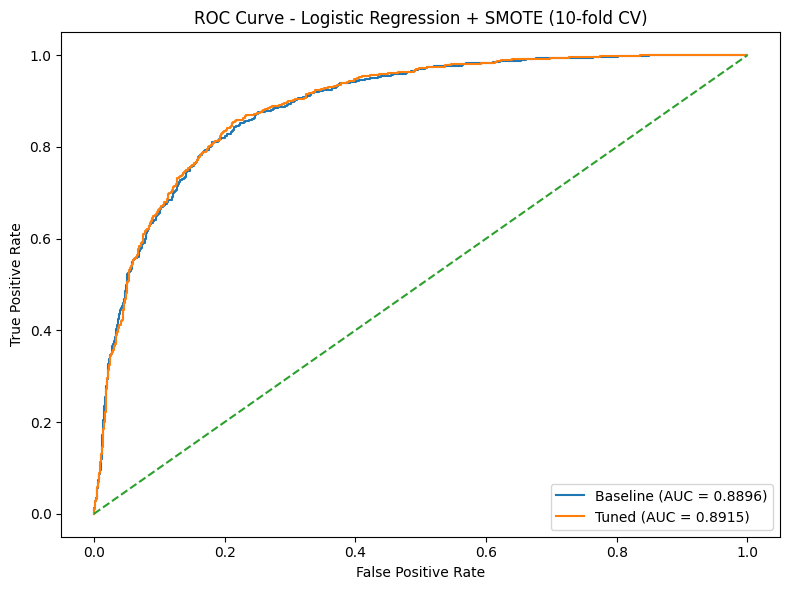

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

# Out-of-fold predicted probabilities
baseline_oof_proba = cross_val_predict(
    baseline_pipeline,
    X,
    y,
    cv=cv10,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

tuned_oof_proba = cross_val_predict(
    tuned_pipeline,
    X,
    y,
    cv=cv10,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# ROC values
fpr_baseline, tpr_baseline, _ = roc_curve(y, baseline_oof_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y, tuned_oof_proba)

auc_baseline = auc(fpr_baseline, tpr_baseline)
auc_tuned = auc(fpr_tuned, tpr_tuned)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_baseline, tpr_baseline, label=f"Baseline (AUC = {auc_baseline:.4f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"Tuned (AUC = {auc_tuned:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression + SMOTE (10-fold CV)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [16]:
# CV configuration
print("Cross-validation configuration:")
print(cv10)

print("\nScoring metrics:")
for k in scoring.keys():
    print("-", k)

print("\nBest parameters from GridSearchCV:")
print(lr_search.best_params_)

print("\nBest mean CV F1-score from GridSearchCV:")
print(round(lr_search.best_score_, 4))

Cross-validation configuration:
StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

Scoring metrics:
- accuracy
- precision
- recall
- f1
- roc_auc

Best parameters from GridSearchCV:
{'model__C': 0.1, 'model__class_weight': None, 'model__solver': 'saga'}

Best mean CV F1-score from GridSearchCV:
0.5187


In [17]:
# Fit tuned pipeline on full dataset to extract final coefficients
tuned_pipeline.fit(X, y)

best_preprocessor = tuned_pipeline.named_steps["preprocessor"]
best_lr = tuned_pipeline.named_steps["lr"]

feature_names = best_preprocessor.get_feature_names_out()
coefficients = best_lr.coef_[0]

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values("Abs_Coefficient", ascending=False)

print(feature_importance_df.head(15))

                  Feature  Coefficient  Abs_Coefficient
49  cat__poutcome_success     1.744800         1.744800
3           num__duration     1.546207         1.546207
42         cat__month_mar     1.408038         1.408038
45         cat__month_oct     1.378361         1.378361
40         cat__month_jul    -1.067485         1.067485
39         cat__month_jan    -1.014739         1.014739
34   cat__contact_unknown    -1.001542         1.001542
44         cat__month_nov    -0.881824         0.881824
50  cat__poutcome_unknown    -0.811944         0.811944
12       cat__job_retired     0.712186         0.712186
47  cat__poutcome_failure    -0.668035         0.668035
32  cat__contact_cellular     0.650274         0.650274
43         cat__month_may    -0.612422         0.612422
31          cat__loan_yes    -0.578854         0.578854
17    cat__job_unemployed    -0.575472         0.575472


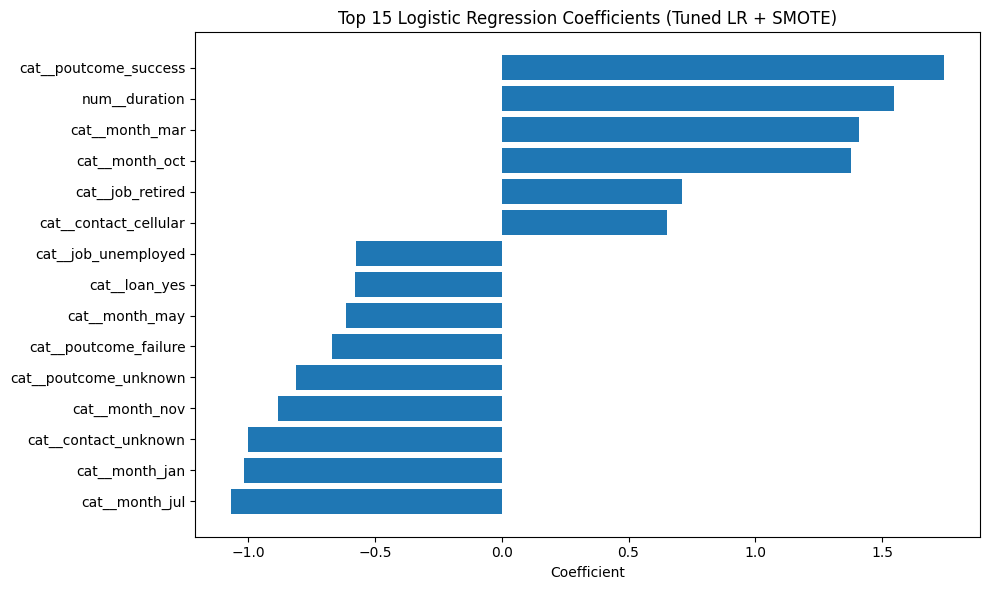

In [18]:
top_features = feature_importance_df.head(15).sort_values("Coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top 15 Logistic Regression Coefficients (Tuned LR + SMOTE)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [19]:
lr_baseline_folds = baseline_folds_df.copy()
lr_baseline_folds["Algorithm"] = "Logistic Regression"
lr_baseline_folds["Version"] = "Baseline"

lr_tuned_folds = tuned_folds_df.copy()
lr_tuned_folds["Algorithm"] = "Logistic Regression"
lr_tuned_folds["Version"] = "Tuned"

lr_cv_folds = pd.concat([lr_baseline_folds, lr_tuned_folds], ignore_index=True)

lr_cv_folds.to_csv("lr_cv_folds.csv", index=False)
lr_cv_folds

,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC,Algorithm,Version
0,1,0.838852,0.405660,0.811321,0.540881,0.892311,Logistic Regression,Baseline
1,2,0.827434,0.361702,0.653846,0.465753,0.875817,Logistic Regression,Baseline
2,3,0.825221,0.373832,0.769231,0.503145,0.869856,Logistic Regression,Baseline
3,4,0.851770,0.417582,0.730769,0.531469,0.895962,Logistic Regression,Baseline
4,5,0.851770,0.424242,0.807692,0.556291,0.918365,Logistic Regression,Baseline
5,6,0.820796,0.361905,0.730769,0.484076,0.880000,Logistic Regression,Baseline
6,7,0.849558,0.428571,0.923077,0.585366,0.935577,Logistic Regression,Baseline
7,8,0.820796,0.359223,0.711538,0.477419,0.876346,Logistic Regression,Baseline
8,9,0.825221,0.363636,0.692308,0.476821,0.848558,Logistic Regression,Baseline
9,10,0.853982,0.427083,0.788462,0.554054,0.913702,Logistic Regression,Baseline
